In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
TEXT_RAW = """
Character prediction is a fundamental task in the field of natural language processing (NLP) that involves
predicting the next character in a sequence of text based on the characters that precede it. This task is
essential for various applications, including text auto-completion, spell checking, and even in the development
of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a
given sequence of text and predict which character is most likely to follow. These predictions are based on
patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks
(RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly
well-suited for sequential data like text, as they can maintain information in memory about previous characters
to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember
long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to
learn the probability of each character's appearance following a sequence of characters. During this training
process, the model adjusts its parameters to minimize the difference between its predictions and the actual
outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the
sequence of characters that precede it. This can enhance user experience in text editing software, improve
efficiency in coding environments with auto-completion features, and enable more natural interactions with
AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP
applications, making text-based interactions more efficient, accurate, and human-like. Through the use of
advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening
new possibilities for the future of text-based technology.
""".strip()


split_idx  = int(len(TEXT_RAW) * 0.9)
TRAIN_TEXT = TEXT_RAW[:split_idx]
VAL_TEXT   = TEXT_RAW[split_idx:]


chars      = sorted(set(TEXT_RAW))
vocab_size = len(chars)
char2idx   = {c: i for i, c in enumerate(chars)}
idx2char   = {i: c for c, i in char2idx.items()}

print(f'Raw corpus : {len(TEXT_RAW):,} characters')
print(f'Train text : {len(TRAIN_TEXT):,} characters')
print(f'Val text   : {len(VAL_TEXT):,} characters')
print(f'Vocabulary : {vocab_size} unique characters')

Raw corpus : 2,384 characters
Train text : 2,145 characters
Val text   : 239 characters
Vocabulary : 46 unique characters


In [ ]:
class CharDataset(Dataset):

    def __init__(self, text, char2idx, seq_len):
        encoded = [char2idx[c] for c in text]
        self.inputs  = []
        self.targets = []
        for i in range(len(encoded) - seq_len):
            self.inputs.append(encoded[i : i + seq_len])
            self.targets.append(encoded[i + seq_len])
        self.inputs  = torch.tensor(self.inputs,  dtype=torch.long)
        self.targets = torch.tensor(self.targets, dtype=torch.long)

    def __len__(self):  return len(self.targets)
    def __getitem__(self, idx): return self.inputs[idx], self.targets[idx]


def make_loaders(seq_len, batch_size=32):
    train_ds = CharDataset(TRAIN_TEXT, char2idx, seq_len)
    val_ds   = CharDataset(VAL_TEXT,   char2idx, seq_len)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size)
    print(f'  seq_len={seq_len}: {len(train_ds):,} train | {len(val_ds):,} val samples')
    return train_loader, val_loader

In [ ]:
class CharModel(nn.Module):

    def __init__(self, vocab_size, embed_dim=32, hidden_size=64,
                 num_layers=1, model_type='RNN', dropout=0.4):
        super().__init__()
        self.model_type  = model_type
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        rnn_kwargs = dict(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        if model_type == 'RNN':
            self.rnn = nn.RNN(**rnn_kwargs, nonlinearity='tanh')
        elif model_type == 'LSTM':
            self.rnn = nn.LSTM(**rnn_kwargs)
        elif model_type == 'GRU':
            self.rnn = nn.GRU(**rnn_kwargs)
        else:
            raise ValueError(f'Unknown model_type: {model_type}')

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        emb    = self.embedding(x)      # (B, T, embed_dim)
        out, _ = self.rnn(emb)          # (B, T, hidden)
        last   = out[:, -1, :]          # final timestep
        logits = self.fc(self.dropout(last))
        return logits

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss   = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        preds   = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


def train_model(model_type, seq_len, epochs=100, lr=1e-3,
                patience=10, save_dir=None):

    train_loader, val_loader = make_loaders(seq_len)

    model     = CharModel(vocab_size, model_type=model_type).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    best_val_loss    = float('inf')
    best_state       = None
    patience_counter = 0
    best_epoch       = 0

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        tr_loss           = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Early stopping, track best val loss
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            best_epoch       = epoch
        else:
            patience_counter += 1

        if epoch % 10 == 0:
            print(f'  [{model_type} | seq={seq_len}] '
                  f'Epoch {epoch:3d} — '
                  f'train={tr_loss:.4f}  val={val_loss:.4f}  acc={val_acc:.3f}  '
                  f'patience={patience_counter}/{patience}')

        if patience_counter >= patience:
            print(f'  Early stop at epoch {epoch} (best epoch: {best_epoch})')
            break

    elapsed = time.time() - t0

    # Restore best weights
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})


    if save_dir:
        path = f'{save_dir}/{model_type}_seq{seq_len}.pt'
        torch.save(model.state_dict(), path)
        print(f'  Saved best checkpoint -> {path}')

    return history, elapsed, model.count_parameters(), best_epoch, model

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/HW2_models'
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
MODEL_TYPES = ['RNN', 'LSTM', 'GRU']
SEQ_LENGTHS = [10, 20, 30]
MAX_EPOCHS  = 100
PATIENCE    = 10

all_results = {}

for mtype, slen in product(MODEL_TYPES, SEQ_LENGTHS):
    print(f' Training {mtype} | seq_len={slen}')
    history, elapsed, n_params, best_epoch, model = train_model(
        mtype, slen,
        epochs=MAX_EPOCHS,
        patience=PATIENCE,
        save_dir=SAVE_DIR
    )
    all_results[(mtype, slen)] = {
        'history'         : history,
        'time_s'          : elapsed,
        'params'          : n_params,
        'best_epoch'      : best_epoch,
        'final_train_loss': history['train_loss'][best_epoch - 1],
        'final_val_loss'  : history['val_loss'][best_epoch - 1],
        'final_val_acc'   : history['val_acc'][best_epoch - 1],
    }
    print(f'  Done in {elapsed:.1f}s | best epoch={best_epoch} | params={n_params:,}')

 Training RNN | seq_len=10
  seq_len=10: 2,135 train | 229 val samples
  [RNN | seq=10] Epoch  10 — train=2.1820  val=2.3246  acc=0.371  patience=0/10
  [RNN | seq=10] Epoch  20 — train=1.8698  val=2.1959  acc=0.428  patience=1/10
  [RNN | seq=10] Epoch  30 — train=1.6679  val=2.1730  acc=0.419  patience=3/10
  [RNN | seq=10] Epoch  40 — train=1.4840  val=2.1948  acc=0.432  patience=8/10
  Early stop at epoch 42 (best epoch: 32)
  Saved best checkpoint -> /content/drive/MyDrive/HW2_models/RNN_seq10.pt
  Done in 8.5s | best epoch=32 | params=10,734
 Training RNN | seq_len=20
  seq_len=20: 2,125 train | 219 val samples
  [RNN | seq=20] Epoch  10 — train=2.2363  val=2.4391  acc=0.347  patience=0/10
  [RNN | seq=20] Epoch  20 — train=1.8857  val=2.2624  acc=0.388  patience=0/10
  [RNN | seq=20] Epoch  30 — train=1.7290  val=2.1884  acc=0.452  patience=0/10
  [RNN | seq=20] Epoch  40 — train=1.5433  val=2.2096  acc=0.447  patience=10/10
  Early stop at epoch 40 (best epoch: 30)
  Saved best

In [ ]:
rows = []
for (mtype, slen), res in all_results.items():
    rows.append({
        'Model'       : mtype,
        'Seq Len'     : slen,
        'Best Epoch'  : res['best_epoch'],
        'Train Loss'  : f"{res['final_train_loss']:.4f}",
        'Val Loss'    : f"{res['final_val_loss']:.4f}",
        'Val Accuracy': f"{res['final_val_acc']:.3f}",
        'Time (s)'    : f"{res['time_s']:.1f}",
        'Parameters'  : f"{res['params']:,}",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df

Model  Seq Len  Best Epoch Train Loss Val Loss Val Accuracy Time (s) Parameters
  RNN       10          32     1.6048   2.1625        0.419      8.5     10,734
  RNN       20          30     1.7290   2.1884        0.452      6.9     10,734
  RNN       30          29     1.6984   2.2693        0.426      6.8     10,734
 LSTM       10          27     1.7187   2.2397        0.397      7.0     29,550
 LSTM       20          38     1.5693   2.2579        0.420      8.9     29,550
 LSTM       30          35     1.5550   2.2226        0.440      8.4     29,550
  GRU       10          33     1.4359   2.1000        0.476      7.8     23,278
  GRU       20          29     1.5621   2.1075        0.466      7.2     23,278
  GRU       30          23     1.6873   2.1834        0.431      6.1     23,278


,Model,Seq Len,Best Epoch,Train Loss,Val Loss,Val Accuracy,Time (s),Parameters
0,RNN,10,32,1.6048,2.1625,0.419,8.5,"10,734"
1,RNN,20,30,1.7290,2.1884,0.452,6.9,"10,734"
2,RNN,30,29,1.6984,2.2693,0.426,6.8,"10,734"
3,LSTM,10,27,1.7187,2.2397,0.397,7.0,"29,550"
4,LSTM,20,38,1.5693,2.2579,0.420,8.9,"29,550"
5,LSTM,30,35,1.5550,2.2226,0.440,8.4,"29,550"
6,GRU,10,33,1.4359,2.1000,0.476,7.8,"23,278"
7,GRU,20,29,1.5621,2.1075,0.466,7.2,"23,278"
8,GRU,30,23,1.6873,2.1834,0.431,6.1,"23,278"


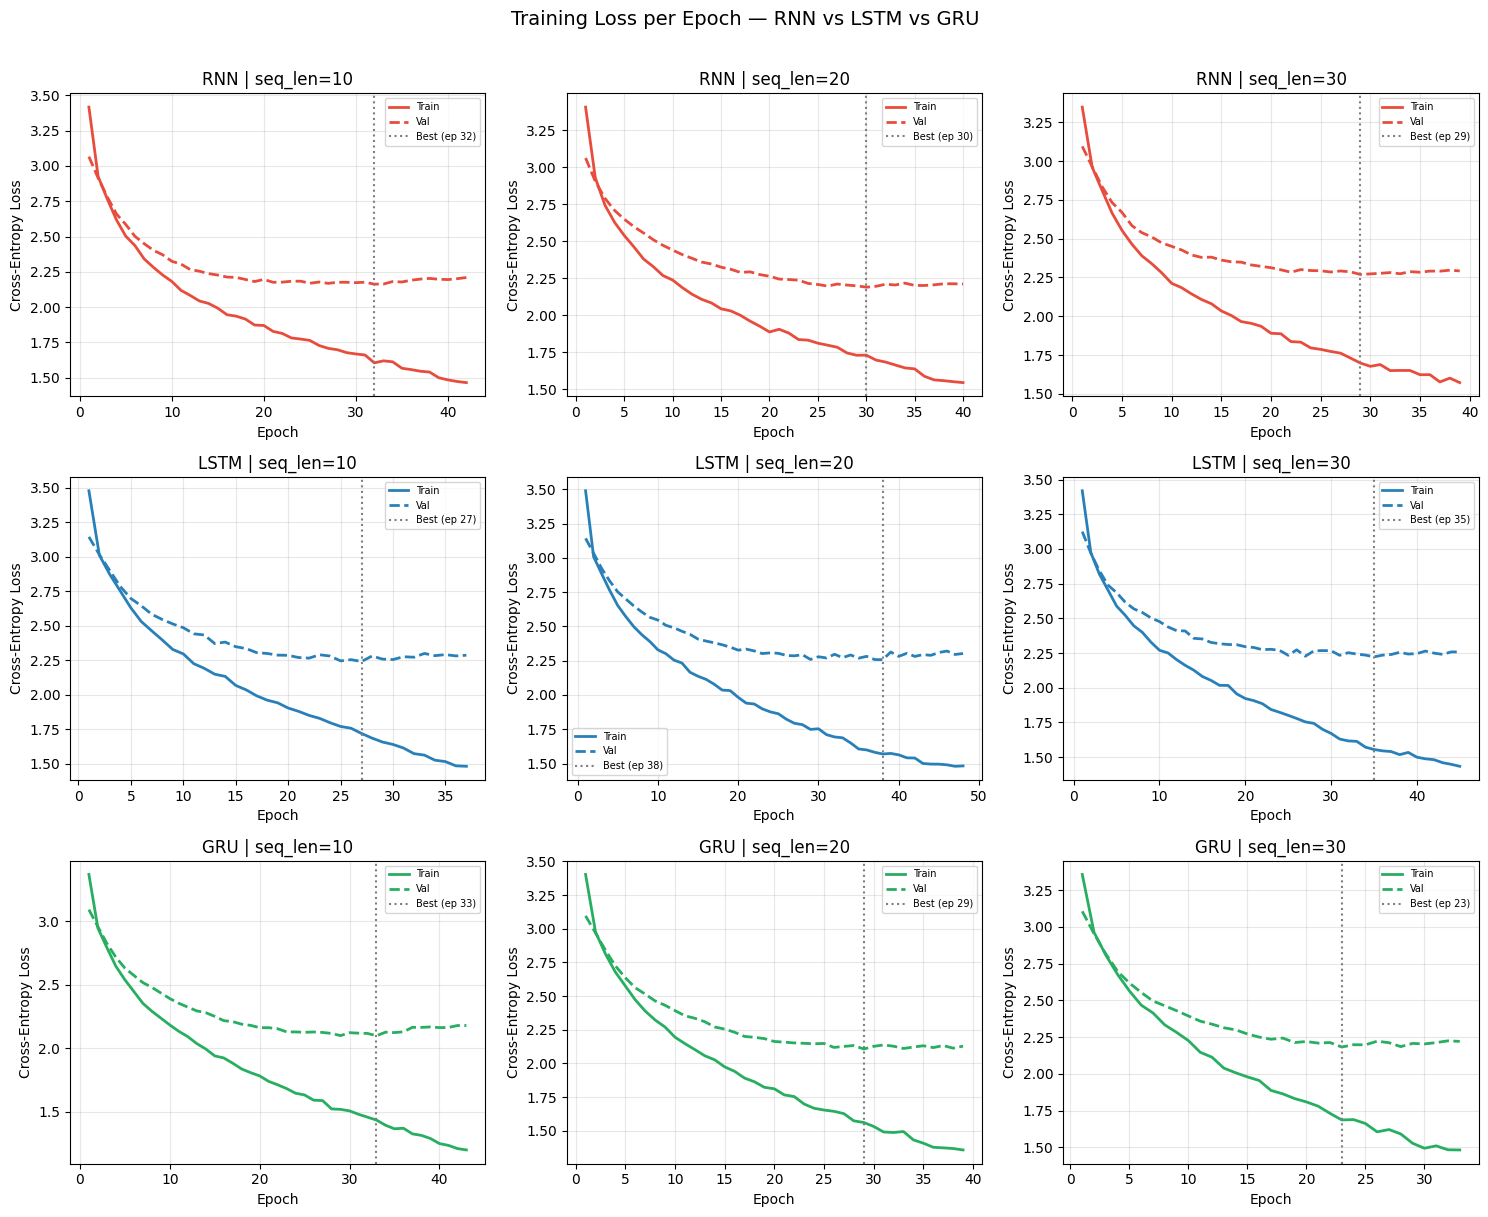

In [ ]:
colors       = {'RNN': '#e74c3c', 'LSTM': '#2980b9', 'GRU': '#27ae60'}

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Training Loss per Epoch — RNN vs LSTM vs GRU', fontsize=14, y=1.01)

for col_idx, slen in enumerate(SEQ_LENGTHS):
    for row_idx, mtype in enumerate(MODEL_TYPES):
        ax      = axes[row_idx][col_idx]
        res     = all_results[(mtype, slen)]
        ep      = range(1, len(res['history']['train_loss']) + 1)
        best_ep = res['best_epoch']

        ax.plot(ep, res['history']['train_loss'],
                label='Train', color=colors[mtype], linewidth=2)
        ax.plot(ep, res['history']['val_loss'],
                label='Val',   color=colors[mtype], linewidth=2, linestyle='--')
        ax.axvline(best_ep, color='gray', linestyle=':', linewidth=1.5,
                   label=f'Best (ep {best_ep})')
        ax.set_title(f'{mtype} | seq_len={slen}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Cross-Entropy Loss')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

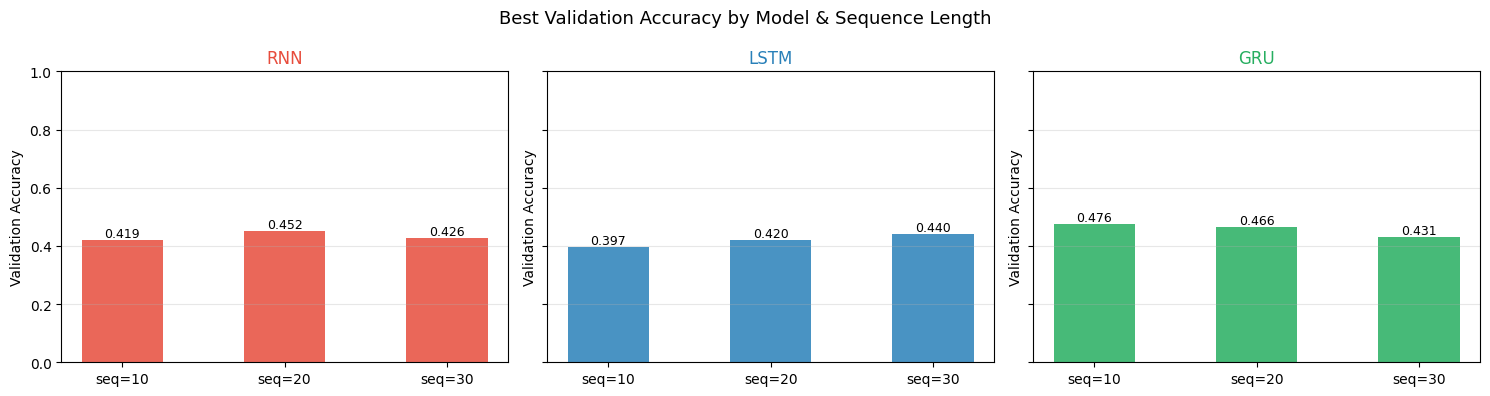

In [ ]:
# Validation Accuracy bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle('Best Validation Accuracy by Model & Sequence Length', fontsize=13)

x = np.arange(len(SEQ_LENGTHS))

for ax_idx, mtype in enumerate(MODEL_TYPES):
    accs = [all_results[(mtype, s)]['final_val_acc'] for s in SEQ_LENGTHS]
    axes[ax_idx].bar(x, accs, color=colors[mtype], width=0.5, alpha=0.85)
    axes[ax_idx].set_title(mtype, fontsize=12, color=colors[mtype])
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels([f'seq={s}' for s in SEQ_LENGTHS])
    axes[ax_idx].set_ylabel('Validation Accuracy')
    axes[ax_idx].set_ylim(0, 1)
    axes[ax_idx].grid(axis='y', alpha=0.3)
    for xi, acc in zip(x, accs):
        axes[ax_idx].text(xi, acc + 0.01, f'{acc:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('val_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

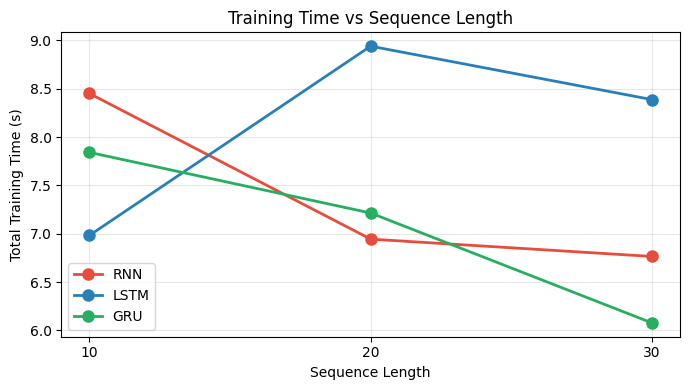

In [ ]:
# Training Time vs Sequence Length
fig, ax = plt.subplots(figsize=(7, 4))

for mtype in MODEL_TYPES:
    times = [all_results[(mtype, s)]['time_s'] for s in SEQ_LENGTHS]
    ax.plot(SEQ_LENGTHS, times, marker='o', label=mtype,
            color=colors[mtype], linewidth=2, markersize=8)

ax.set_title('Training Time vs Sequence Length', fontsize=12)
ax.set_xlabel('Sequence Length')
ax.set_ylabel('Total Training Time (s)')
ax.set_xticks(SEQ_LENGTHS)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_time.png', dpi=150, bbox_inches='tight')
plt.show()


RNN   :     10,734 parameters
LSTM  :     29,550 parameters
GRU   :     23,278 parameters


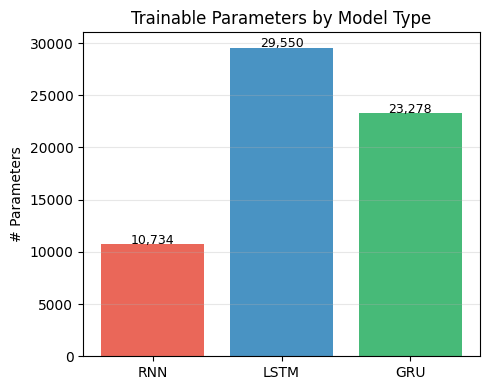

In [ ]:
for mtype in MODEL_TYPES:
    p = all_results[(mtype, SEQ_LENGTHS[0])]['params']
    print(f'{mtype:6s}: {p:>10,} parameters')

fig, ax = plt.subplots(figsize=(5, 4))
param_counts = [all_results[(m, SEQ_LENGTHS[0])]['params'] for m in MODEL_TYPES]
ax.bar(MODEL_TYPES, param_counts,
       color=[colors[m] for m in MODEL_TYPES], alpha=0.85)
for xi, (m, p) in enumerate(zip(MODEL_TYPES, param_counts)):
    ax.text(xi, p + 50, f'{p:,}', ha='center', fontsize=9)
ax.set_title('Trainable Parameters by Model Type')
ax.set_ylabel('# Parameters')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_size.png', dpi=150, bbox_inches='tight')
plt.show()